In [191]:
import os
import pandas as pd
import numpy as np
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st # for Cumulative Distribution Function in VdW score 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Load the data (download pre_processing.csv from ".....")

In [192]:
df = pd.read_parquet('datasets/pre_processing.parquet')

In [193]:
df_capital = df[df['mun_istat'] == df['cap_mun_istat']].copy()

Keep data with listings over 11 years

In [194]:
# count number of years per id
obs_per_id = df.groupby(['mun_istat'])['year'].nunique()

# count how many ids have 1 year, 2 years, etc.
count_by_years = obs_per_id.value_counts().sort_index()

print(count_by_years)

year
1        2
2        1
3       21
4        5
5        1
7       38
8        7
9        6
10      21
11    7771
Name: count, dtype: int64


In [195]:
# keep only ids with listings over 11 years - balanced panel data
ids_eleven = obs_per_id[obs_per_id == 11].index

# filter the data
df = df[df['mun_istat'].isin(ids_eleven)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85481 entries, 0 to 86158
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   mun_istat                 85481 non-null  object  
 1   year                      85481 non-null  int64   
 2   mun_name                  85481 non-null  object  
 3   mun_name_norm             85481 non-null  object  
 4   location                  85481 non-null  category
 5   region                    85481 non-null  object  
 6   prov                      85481 non-null  object  
 7   buy_min                   85481 non-null  float64 
 8   buy_max                   85481 non-null  float64 
 9   prov_istat                85481 non-null  object  
 10  population                85481 non-null  float64 
 11  surface                   85481 non-null  float64 
 12  median_income             85481 non-null  float64 
 13  changed                   85481 non-null  bool    


Cumulative data per province (population, dwellings, tourism values)

In [196]:
sum_col = [
    'population', 
    'dwellings', 
    'surface', 
    'five_stars_beds',
    'four_stars_beds',
    'three_stars_beds',
    'two_stars_beds',
    'one_stars_beds',
    'holiday_dwelling_count',
    'holiday_dwelling_beds',
    "tourism_residence_beds",
    "camp_sites_beds",
    "farmhouses_beds",
    "hostels_beds",
    "tourist_dormitories_beds",
    "mountain_huts_beds",
    "bnb_beds",
    'tot_count',
    'tot_acc_beds',
    'tot_beds',
    'tot_arrivals_residents',
    'tot_arrivals_foreigners',
    'tot_arrivals',
    'tot_nights_residents',
    'tot_nights_foreigners',
    'tot_nights']

for col in sum_col:
    df['prov_' + col] = df.groupby(['year', 'prov'], observed=True)[col].transform('sum')

Weighted averages per province (buy_min, buy_max, median_income)

In [197]:
# buy_min * dwellings
df['buy_min_fraction'] = (df['buy_min'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_min_wgt'] = df.groupby(['year','prov'], observed=True)['buy_min_fraction'].transform('sum')

# buy_max * dwellings
df['buy_max_fraction'] = (df['buy_max'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_max_wgt'] = df.groupby(['year','prov'], observed=True)['buy_max_fraction'].transform('sum')

# median_income * population
df['median_income_fraction'] = (df['median_income'] * df['population']) / df['prov_population']
df['prov_median_income_wgt'] = df.groupby(['year','prov'], observed=True)['median_income_fraction'].transform('sum')

# drop fraction cols
df = df.drop(columns = ['buy_min_fraction', 'buy_max_fraction', 'median_income_fraction'])

Immigration and emigration ratios

In [198]:
# total number of immigrants and emigrants (standardized per 100 inhabitants) - SEMI-ELASTICITY
df['prov_immigration'] = ((df['abroad_in'] + df['nation_in']) / df['population']) * 100

df['prov_emigration'] = ((df['abroad_out'] + df['nation_out']) / df['population']) * 100

Tourism indexes

In [199]:
# total number of hotel beds
hotel_col = [
    'prov_five_stars_beds',
    'prov_four_stars_beds',
    'prov_three_stars_beds',
    'prov_two_stars_beds',
    'prov_one_stars_beds'
]

df['prov_hotel_beds'] = df[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df = df.drop(columns = hotel_col)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) 
df['prov_ratio_hotel_beds'] = (df['prov_hotel_beds'] / df['prov_population']) * 100

#################################

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and population (per 100 dwellings) 
df['prov_ratio_str_houses'] = (df['prov_holiday_dwelling_count'] / df['prov_dwellings']) * 100

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) 
df['prov_ratio_str_beds'] = (df['prov_holiday_dwelling_beds'] / df['prov_population']) * 100

#################################

# OTHER ACCOMODATIONS PRESSURE ON MUNICIPALITY - ratio between other accommodation beds and population (per 100 inhabitants) 
df['prov_other_acc_beds'] = ((df['prov_tot_beds'] - df['prov_hotel_beds'] - df['prov_holiday_dwelling_beds']) / df['prov_population']) * 100

#################################

# measure the ratio between arrivals and population (per 100 inhabitants) 
df['prov_ratio_arrivals_residents'] = (df['prov_tot_arrivals_residents'] / df['prov_population']) * 100

# measure the ratio between foreigner arrivals and population (per 100 inhabitants) 
df['prov_ratio_arrivals_foreigners'] = (df['prov_tot_arrivals_foreigners'] / df['prov_population']) * 100

# measure the ratio between total arrivals and population (per 100 inhabitants) 
df['prov_ratio_tot_arrivals'] = (df['prov_tot_arrivals'] / df['prov_population']) * 100

#################################

# measure the ratio between residents nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights_residents'] = (df['prov_tot_nights_residents'] / df['prov_population']) * 100

# measure the ratio between foreigner nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights_foreigners'] = (df['prov_tot_nights_foreigners'] / df['prov_population']) * 100

# measure the ratio between total nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights'] = (df['prov_tot_nights'] / df['prov_population']) * 100

#################################

# measure the ratio between total beds and population (per 100 inhabitants) - FOR INDEX BRAKE DOWN
df['prov_ratio_tot_beds'] = (df['prov_tot_beds'] / df['prov_population']) * 100

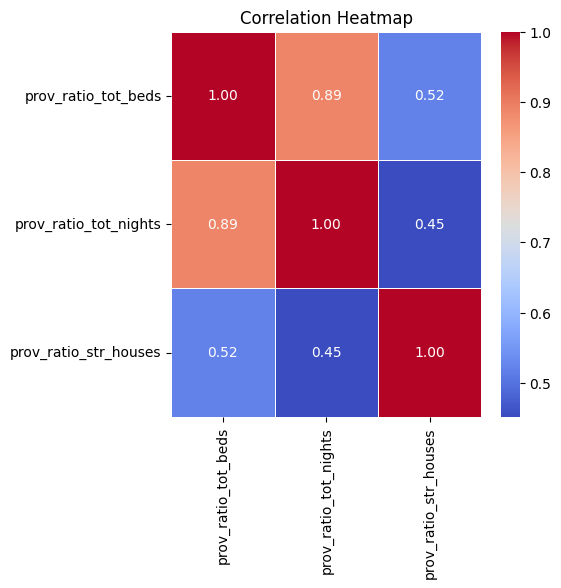

In [200]:
# correlation matrix
var_corr = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

matrix = df[var_corr].corr()

plt.figure(figsize=(5,5))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [201]:
# compute Van der Waerden score as a tourist index - consider prov_ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vars_tourism = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

for col in vars_tourism:
    df[col + '_vdw'] = van_der_waerden_score(df[col])

# composite index based on VdW scores (average value)
df['tourism_index_vdw'] = df[[v + '_vdw' for v in vars_tourism]].mean(axis=1)

# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_vdw'].min())
print("Maximum tourism score: ", df['tourism_index_vdw'].max())

Minimum tourism score:  1.1961582555391779
Maximum tourism score:  99.36419363140779


In [202]:
# Standardize
X = StandardScaler().fit_transform(df[vars_tourism])

# PCA with 1 component
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X)[:, 0]

# Variance explained
print("Variance explained by first component:", pca.explained_variance_ratio_[0])

# Shift to make positive
pc1_positive = pc1 - pc1.min() + 1e-6

# Scale 0–100
df['tourism_index_pca'] = 100 * (pc1_positive / pc1_positive.max())

# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_pca'].min())
print("Maximum tourism score: ", df['tourism_index_pca'].max())

Variance explained by first component: 0.7551281417794936
Minimum tourism score:  8.702166876586306e-06
Maximum tourism score:  100.0


Group by province

In [203]:
df_prov = df.groupby(['year','prov'], observed=True).agg({
    'location':'first',
    'region':'first',
    'prov_buy_min_wgt':'first',
    'prov_buy_max_wgt':'first',
    'prov_median_income_wgt':'first',
    'prov_population':'first',
    'prov_surface' : 'first',
    'prov_dwellings':'first',
    'prov_immigration':'first',
    'prov_emigration':'first',
    'prov_unemployment':'first',
    'over65':'first',
    'reg_age_avg':'first',
    'prov_ratio_hotel_beds':'first',
    'prov_ratio_str_beds':'first',
    'prov_ratio_str_houses':'first',
    'prov_other_acc_beds' : 'first',
    'prov_ratio_arrivals_residents':'first',
    'prov_ratio_arrivals_foreigners':'first',
    'prov_ratio_tot_arrivals' : 'first',
    'prov_ratio_tot_nights_residents':'first',
    'prov_ratio_tot_nights_foreigners':'first',
    'prov_ratio_tot_nights' : 'first',
    'prov_ratio_tot_beds' : 'first',
    'tourism_index_vdw':'first',
    'tourism_index_pca':'first',
    'tour_employed':'first',
    'real_gdp':'first',
    'nominal_gdp':'first',
    'cpi_index' : 'first',
    'life':'first',
    'interest_rate':'first'
}).reset_index()

Log transform

In [204]:
log_col = ['prov_buy_min_wgt',
           'prov_buy_max_wgt',
           'prov_population',
           'prov_dwellings',
           'prov_surface',
           'prov_median_income_wgt',
           'prov_immigration',
           'prov_emigration',
           'tourism_index_vdw',
           'tourism_index_pca',
           'real_gdp',
           'nominal_gdp',
           'tour_employed',
           'reg_age_avg',
           'over65',
           'life',
           'prov_unemployment',
           'interest_rate',
           'cpi_index',
           'prov_ratio_hotel_beds',
           'prov_ratio_str_houses',
           'prov_ratio_str_beds',
           'prov_other_acc_beds',
           'prov_ratio_arrivals_residents',
           'prov_ratio_arrivals_foreigners',
           'prov_ratio_tot_arrivals',
           'prov_ratio_tot_nights_residents',
           'prov_ratio_tot_nights_foreigners',
           'prov_ratio_tot_nights',
           'prov_ratio_tot_beds']

for col in log_col:
    df_prov['log_' + col] = np.log(df_prov[col] + 1e-6)  # add a small constant to avoid log(0)

Growth rates

In [205]:
diff_col = ['log_prov_buy_min_wgt',
           'log_prov_buy_max_wgt',
           'log_prov_population',
           'log_prov_dwellings',
           'log_prov_surface',
           'log_prov_median_income_wgt',
           'log_prov_immigration',
           'log_prov_emigration',
           'log_tourism_index_vdw',
           'log_tourism_index_pca',
           'log_real_gdp',
           'log_nominal_gdp',
           'log_tour_employed',
           'log_reg_age_avg',
           'log_over65',
           'log_life',
           'log_prov_unemployment',
           'log_interest_rate',
           'log_cpi_index',
           'log_prov_ratio_hotel_beds',
           'log_prov_ratio_str_houses',
           'log_prov_ratio_str_beds',
           'log_prov_other_acc_beds',
           'log_prov_ratio_arrivals_residents',
           'log_prov_ratio_arrivals_foreigners',
           'log_prov_ratio_tot_arrivals',
           'log_prov_ratio_tot_nights_residents',
           'log_prov_ratio_tot_nights_foreigners',
           'log_prov_ratio_tot_nights',
           'log_prov_ratio_tot_beds']

for col in diff_col:
    df_prov['d_' + col] = df_prov.groupby('prov')[col].diff()

Dummies

In [206]:
# covid dummy
df_prov['covid'] = np.where(df_prov['year'] < 2020, 0, 1)

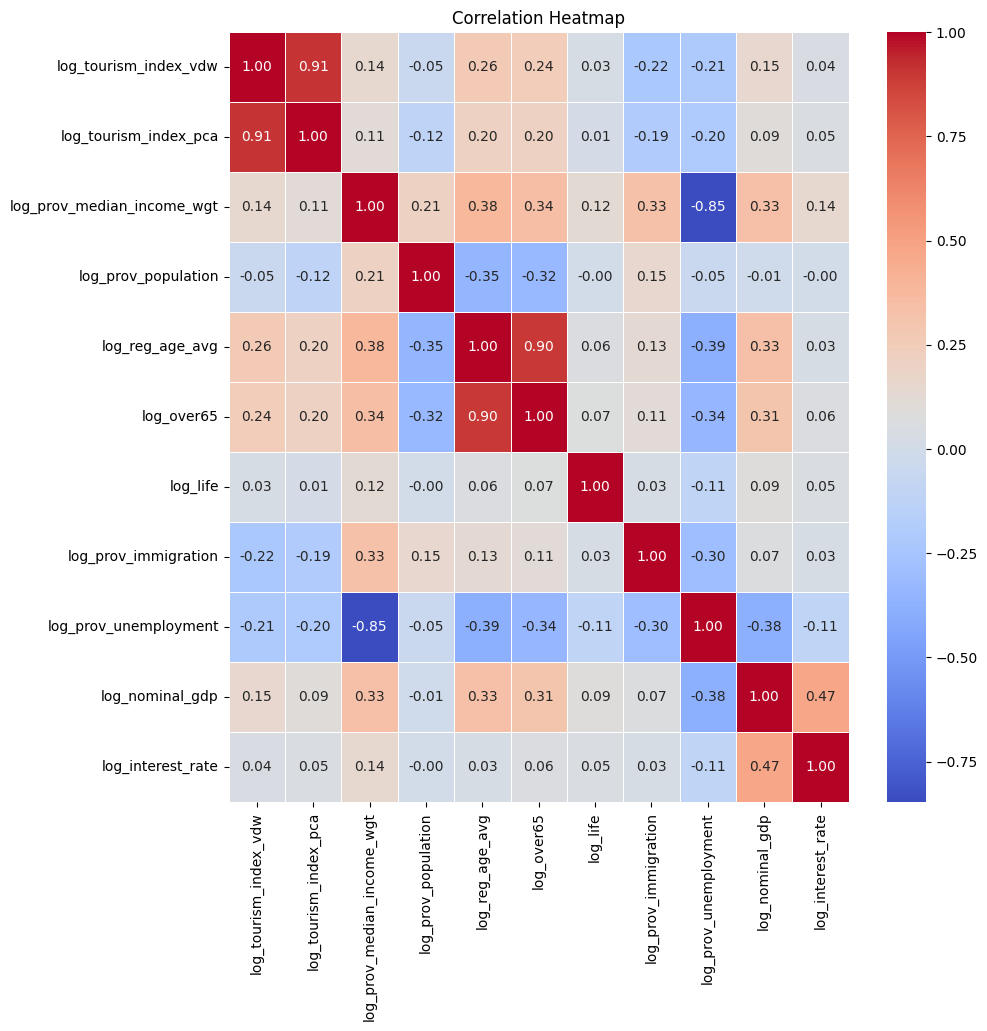

In [207]:
# correlation matrix
var_corr = [
    'log_tourism_index_vdw',
    'log_tourism_index_pca',
    'log_prov_median_income_wgt',
    'log_prov_population',
    'log_reg_age_avg',
    'log_over65',
    'log_life',
    'log_prov_immigration',
    'log_prov_unemployment',
    'log_nominal_gdp',
    'log_interest_rate'
]

matrix = df_prov[var_corr].corr()

plt.figure(figsize=(10,10))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Perform the same operations on df_capital

In [208]:
# total number of immigrants, emigrants, and net movements (standardized per 100 inhabitants) - SEMI-ELASTICITY
df_capital['prov_immigration'] = ((df_capital['abroad_in'] + df_capital['nation_in']) / df_capital['population']) * 100

df_capital['prov_emigration'] = ((df_capital['abroad_out'] + df_capital['nation_out']) / df_capital['population']) * 100

In [209]:
# total number of hotel beds
hotel_col = [
    'five_stars_beds',
    'four_stars_beds',
    'three_stars_beds',
    'two_stars_beds',
    'one_stars_beds'
]

df_capital['hotel_beds'] = df_capital[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df_capital = df_capital.drop(columns = hotel_col)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_hotel_beds'] = (df_capital['hotel_beds'] / df_capital['population']) * 100

#############################################

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and population (per 100 dwellings) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_str_houses'] = (df_capital['holiday_dwelling_beds'] / df_capital['dwellings']) * 100

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_str_beds'] = (df_capital['holiday_dwelling_beds'] / df_capital['population']) * 100

#################################

# OTHER ACCOMODATIONS PRESSURE ON MUNICIPALITY - ratio between other accommodation beds and population (per 100 inhabitants) 
df_capital['other_acc_beds'] = ((df_capital['tot_beds'] - df_capital['hotel_beds'] - df_capital['holiday_dwelling_beds']) / df_capital['population']) * 100

#################################

# measure the ratio between residents arrivals and population (per 100 inhabitants) 
df_capital['ratio_arrivals_residents'] = (df_capital['tot_arrivals_residents'] / df_capital['population']) * 100

# measure the ratio between foreigner arrivals and population (per 100 inhabitants) 
df_capital['ratio_arrivals_foreigners'] = (df_capital['tot_arrivals_foreigners'] / df_capital['population']) * 100


# measure the ratio between total arrivals and population (per 100 inhabitants) 
df_capital['ratio_tot_arrivals'] = (df_capital['tot_arrivals'] / df_capital['population']) * 100

#################################

# measure the ratio between residents nights  and population (per 100 inhabitants)
df_capital['ratio_tot_nights_residents'] = (df_capital['tot_nights_residents'] / df_capital['population']) * 100

# measure the ratio between foreigner nights and population (per 100 inhabitants)
df_capital['ratio_tot_nights_foreigners'] = (df_capital['tot_nights_foreigners'] / df_capital['population']) * 100

# measure the ratio between total nights and population (per 100 inhabitants)
df_capital['ratio_tot_nights'] = (df_capital['tot_nights'] / df_capital['population']) * 100

##################################

# measure the ratio between total beds and population (per 100 inhabitants) - FOR INDEX BRAKE DOWN
df_capital['ratio_tot_beds'] = (df_capital['tot_beds'] / df_capital['population']) * 100

In [210]:
# compute Van der Waerden score as a tourist index - consider ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vars_tourism = [
    'ratio_tot_beds',
    'ratio_tot_nights',
    'ratio_str_houses'
]

for col in vars_tourism:
    df_capital[col + '_vdw'] = van_der_waerden_score(df_capital[col])

# composite index based on VdW scores (average value)
df_capital['tourism_index_vdw'] = df_capital[[v + '_vdw' for v in vars_tourism]].mean(axis=1)

# check minimum and maximum tourism score
print("Minimum tourism score: ", df_capital['tourism_index_vdw'].min())
print("Maximum tourism score: ", df_capital['tourism_index_vdw'].max())

Minimum tourism score:  0.3440682631434076
Maximum tourism score:  99.00908340214698


In [211]:
# Standardize
X = StandardScaler().fit_transform(df_capital[vars_tourism])

# PCA with 1 component
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X)[:, 0]

# Variance explained
print("Variance explained by first component:", pca.explained_variance_ratio_[0])

# Shift to make positive
pc1_positive = pc1 - pc1.min() + 1e-6

# Scale 0–100
df_capital['tourism_index_pca'] = 100 * (pc1_positive / pc1_positive.max())

# check minimum and maximum tourism score
print("Minimum tourism score: ", df_capital['tourism_index_pca'].min())
print("Maximum tourism score: ", df_capital['tourism_index_pca'].max())

Variance explained by first component: 0.7316192830735603
Minimum tourism score:  8.546894229723431e-06
Maximum tourism score:  100.0


In [212]:
log_col = ['buy_min',
           'buy_max',
           'population',
           'dwellings',
           'surface',
           'median_income',
           'prov_immigration',
           'prov_emigration',
           'tourism_index_vdw',
           'tourism_index_pca',
           'real_gdp',
           'nominal_gdp',
           'tour_employed',
           'reg_age_avg',
           'over65',
           'life',
           'prov_unemployment',
           'interest_rate',
           'cpi_index',
           'ratio_hotel_beds',
           'ratio_str_houses',
           'ratio_str_beds',
           'other_acc_beds',
           'ratio_arrivals_residents',
           'ratio_arrivals_foreigners',
           'ratio_tot_arrivals',
           'ratio_tot_nights_residents',
           'ratio_tot_nights_foreigners',
           'ratio_tot_nights',
           'ratio_tot_beds']

(df_capital[log_col] == 0).sum()

buy_min                         0
buy_max                         0
population                      0
dwellings                       0
surface                         1
median_income                   0
prov_immigration                0
prov_emigration                 0
tourism_index_vdw               0
tourism_index_pca               0
real_gdp                        0
nominal_gdp                     0
tour_employed                   0
reg_age_avg                     0
over65                          0
life                            0
prov_unemployment               0
interest_rate                   0
cpi_index                       0
ratio_hotel_beds                2
ratio_str_houses               18
ratio_str_beds                 18
other_acc_beds                  0
ratio_arrivals_residents        1
ratio_arrivals_foreigners       1
ratio_tot_arrivals              1
ratio_tot_nights_residents      1
ratio_tot_nights_foreigners     1
ratio_tot_nights                1
ratio_tot_beds

In [213]:
for col in log_col:
    df_capital['log_' + col] = np.log(df_capital[col] + 1e-6)

diff_col = ['log_buy_min',
           'log_buy_max',
           'log_population',
           'log_dwellings',
           'log_surface',
           'log_median_income',
           'log_prov_immigration',
           'log_prov_emigration',
           'log_tourism_index_vdw',
           'log_tourism_index_pca',
           'log_real_gdp',
           'log_nominal_gdp',
           'log_tour_employed',
           'log_reg_age_avg',
           'log_over65',
           'log_life',
           'log_prov_unemployment',
           'log_interest_rate',
           'log_cpi_index',
           'log_ratio_hotel_beds',
           'log_ratio_str_houses',
           'log_ratio_str_beds',
           'log_other_acc_beds',
           'log_ratio_arrivals_residents',
           'log_ratio_arrivals_foreigners',
           'log_ratio_tot_arrivals',
           'log_ratio_tot_nights_residents',
           'log_ratio_tot_nights_foreigners',
           'log_ratio_tot_nights',
           'log_ratio_tot_beds']

for col in diff_col:
    df_capital['d_' + col] = df_capital.groupby('mun_istat')[col].diff()

In [214]:
# covid dummy
df_capital['covid'] = np.where(df_capital['year'] < 2020, 0, 1)

In [215]:
col = ['mun_istat',
       'year',
       'location',
       'region',
       'prov',
       'log_buy_min',
       'log_buy_max',
       'log_population',
       'log_median_income',
       'log_prov_immigration',
       'log_prov_emigration',
       'log_tourism_index_vdw',
       'log_tourism_index_pca',
       'log_real_gdp',
       'log_nominal_gdp',
       'log_tour_employed',
       'log_reg_age_avg',
       'log_over65',
       'log_life',
       'log_prov_unemployment',
       'log_interest_rate',
       'log_ratio_hotel_beds',
       'log_ratio_str_houses',
       'log_ratio_str_beds',
       'log_other_acc_beds',
       'log_ratio_arrivals_residents',
       'log_ratio_arrivals_foreigners',
       'log_ratio_tot_arrivals',
       'log_ratio_tot_nights_residents',
       'log_ratio_tot_nights_foreigners',
       'log_ratio_tot_nights',
       'log_ratio_tot_beds',
       'd_log_buy_min',
       'd_log_buy_max',
       'd_log_population',
       'd_log_median_income',
       'd_log_prov_immigration',
       'd_log_prov_emigration',
       'd_log_tourism_index_vdw',
       'd_log_tourism_index_pca',
       'd_log_real_gdp',
       'd_log_nominal_gdp',
       'd_log_tour_employed',
       'd_log_reg_age_avg',
       'd_log_over65',
       'd_log_life',
       'd_log_prov_unemployment',
       'd_log_interest_rate',
       'd_log_ratio_hotel_beds',
       'd_log_ratio_str_houses',
       'd_log_ratio_str_beds',
       'd_log_other_acc_beds',
       'd_log_ratio_arrivals_residents',
       'd_log_ratio_arrivals_foreigners',
       'd_log_ratio_tot_arrivals',
       'd_log_ratio_tot_nights_residents',
       'd_log_ratio_tot_nights_foreigners',
       'd_log_ratio_tot_nights',
       'd_log_ratio_tot_beds',
       'covid', 
       'log_cpi_index', 
       'd_log_cpi_index']

df_capital = df_capital[col]

Save the data

In [216]:
df_prov.to_csv('datasets/model.csv', index = False)
df_capital.to_csv('datasets/model_capital.csv', index = False)

In [217]:
df_prov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 95 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   year                                    1210 non-null   int64   
 1   prov                                    1210 non-null   object  
 2   location                                1210 non-null   category
 3   region                                  1210 non-null   object  
 4   prov_buy_min_wgt                        1210 non-null   float64 
 5   prov_buy_max_wgt                        1210 non-null   float64 
 6   prov_median_income_wgt                  1210 non-null   float64 
 7   prov_population                         1210 non-null   float64 
 8   prov_surface                            1210 non-null   float64 
 9   prov_dwellings                          1210 non-null   float64 
 10  prov_immigration                        1210 non

<Axes: xlabel='year', ylabel='log_nominal_gdp'>

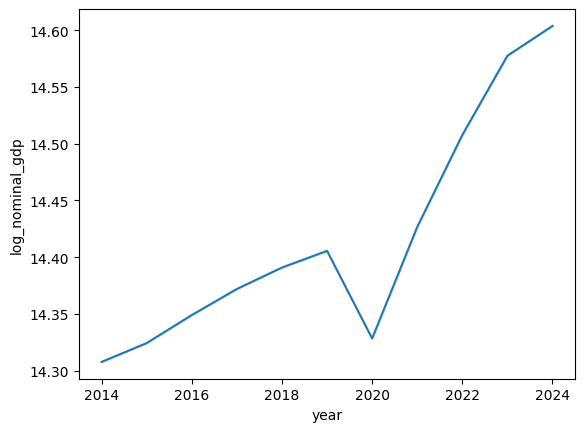

In [218]:
sns.lineplot(data=df_prov, x = 'year', y = 'log_nominal_gdp')

In [219]:
# correlation matrix
var_corr = [
    'log_tourism_index_vdw',
    'log_tourism_index_pca'

]

matrix = df_prov[var_corr].corr()

matrix

,log_tourism_index_vdw,log_tourism_index_pca
log_tourism_index_vdw,1.000000,0.911037
log_tourism_index_pca,0.911037,1.000000
